In [47]:
%pip install tensorflow

## Mount google drive

### Subtask:
Mount Google Drive to access the image data.


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load and prepare data

### Subtask:
Load the images from the specified folders, preprocess them, and create datasets for training, validation, and testing.


**Reasoning**:
Define the paths for the datasets and load and preprocess the images using `image_dataset_from_directory` to create TensorFlow datasets for training, validation, and testing.



In [49]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import preprocess_input
base_dir = '/content/drive/MyDrive/Record học/'

# Define paths for training, validation, and test sets
train_dir = base_dir + 'training_set/training_set_augmented'
validation_dir = base_dir + 'validation_set/validation_augmented'
test_dir = base_dir + 'test_set/test_set_augmented'

# Define image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

# Load and preprocess training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load and preprocess validation data
validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load and preprocess test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Function to scale pixel values to [0, 1]
def preprocess(image, label):
  image = tf.cast(image, tf.float32)
  # nếu ảnh đang ở [0,1] thì nhân lên 255; nếu đã ở [0,255] thì giữ nguyên
  image = tf.cond(tf.reduce_max(image) <= 1.0,
                    lambda: image * 255.0,
                    lambda: image)
  image = preprocess_input(image)   # MobileNet expects 0-255 -> returns ~[-1,1]
  return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets created successfully:")
print(f"Training dataset: {train_ds}")
print(f"Validation dataset: {validation_ds}")
print(f"Test dataset: {test_ds}")

Found 420 files belonging to 2 classes.
Found 120 files belonging to 2 classes.
Found 180 files belonging to 2 classes.
Datasets created successfully:
Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


Check data

In [50]:
# Tạo lại dataset (không map preprocess) chỉ để kiểm tra class_names/hiển thị
raw_train = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    interpolation='bilinear'
)

print("Class names (label index order):", raw_train.class_names)
# Với folder names ['hemmorhage_data','non_hemmorhage_data'],
# label 0 -> 'hemmorhage_data', label 1 -> 'non_hemmorhage_data' (alphabetical order)


Found 420 files belonging to 2 classes.
Class names (label index order): ['hemmorhage_data', 'non_hemmorhage_data']


/tmp/ipython-input-3255402407.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(raw_train.class_names[int(labels[i])])


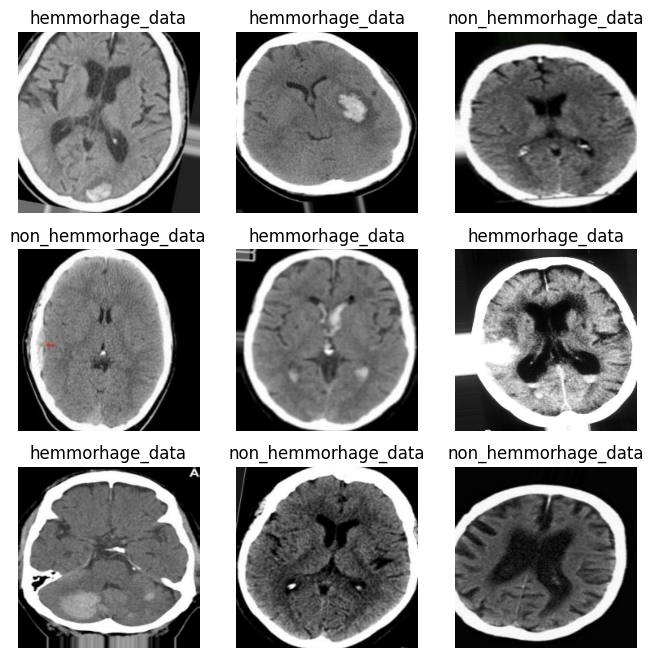

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
for images, labels in raw_train.take(1):   # 1 batch
    images = images.numpy().astype("uint8")
    labels = labels.numpy()
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(raw_train.class_names[int(labels[i])])
        plt.axis('off')
plt.show()


In [52]:
import os
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes in FS (alphabetical):", classes)

for idx, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    sample_files = os.listdir(folder)[:5]
    print(f"Label {idx} -> {cls}, sample files: {sample_files}")


Classes in FS (alphabetical): ['hemmorhage_data', 'non_hemmorhage_data']
Label 0 -> hemmorhage_data, sample files: ['051_0_5759.jpg', '080_0_1020.jpg', '066_0_3197.jpg', '050_0_6699.jpg', '070_0_1485.jpg']
Label 1 -> non_hemmorhage_data, sample files: ['196_0_9261.jpg', '187_0_5104.jpg', '189_0_1769.jpg', '189_0_8301.jpg', '197_0_756.jpg']


In [53]:
import numpy as np

def count_labels(ds):
    counts = np.zeros(2, dtype=int)
    for images, labels in ds.unbatch():
        counts[int(labels.numpy())] += 1
    return counts

# dùng raw_train hoặc recreate dataset với batch_size lớn để count nhanh:
big = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=(IMG_HEIGHT,IMG_WIDTH), batch_size=1024, shuffle=False)
print("Train label counts:", count_labels(big))


Found 420 files belonging to 2 classes.
Train label counts: [210 210]


## Build and compile the model

### Subtask:
Build a MobileNetV1 model for binary classification and compile it with an appropriate optimizer, loss function, and metrics.

**Reasoning**:
Define and compile the MobileNetV1 model using `MobileNetV1` from `tensorflow.keras.applications` with pre-trained weights from ImageNet, and add a dense layer for binary classification. Use Adam optimizer, Binary Crossentropy loss, and Accuracy metric.

In [54]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model


IMG_HEIGHT, IMG_WIDTH = 224, 224

# Load MobileNetV1 (chính là MobileNet) pretrained trên ImageNet
base_model = MobileNet(weights='imagenet',
                       include_top=False,
                       input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Add a global average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Add a dropout layer
x = Dropout(0.5)(x) # You can adjust the dropout rate

# Add a dense layer for binary classification
predictions = Dense(1, activation='sigmoid')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[
                  'accuracy',
                  tf.keras.metrics.AUC(name='auc'),
                  tf.keras.metrics.Precision(name='precision'),
                  tf.keras.metrics.Recall(name='recall'),
                ])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,229,889 (12.32 MB)

 Trainable params: 3,208,001 (12.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

## Train the model

### Subtask:
Train the compiled model using the training and validation datasets.

**Reasoning**:
Train the model using the `fit` method with the training and validation datasets. Specify the number of epochs.

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 60  # You can adjust the number of epochs

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) # You can adjust patience

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping] # Add Early Stopping callback
)

Epoch 1/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 49s 6s/step - accuracy: 0.7281 - auc: 0.7871 - loss: 0.6125 - precision: 0.7128 - recall: 0.7850 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 7.4726 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 314ms/step - accuracy: 0.9758 - auc: 0.9984 - loss: 0.0559 - precision: 0.9832 - recall: 0.9685 - val_accuracy: 0.5000 - val_auc: 0.6500 - val_loss: 3.5798 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.9932 - auc: 1.0000 - loss: 0.0137 - precision: 0.9970 - recall: 0.9895 - val_accuracy: 0.5333 - val_auc: 0.7083 - val_loss: 2.5997 - val_precision: 0.5172 - val_recall: 1.0000
Epoch 4/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 325ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0031 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.6500 - val_auc: 0.8417 - val_loss: 1.8168 - val_precision: 0.5882 - val_recall: 1.0000
Epoch 5/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 31

## Evaluate the model

### Subtask:
Evaluate the trained model using the test dataset to assess its performance on unseen data.

**Reasoning**:
Evaluate the trained model on the test dataset using the `evaluate` method to determine its loss and accuracy on unseen data.

In [56]:
# Evaluate the model on the test set
probs = model.predict(test_ds).ravel()   # (N,)
results = model.evaluate(test_ds)
y_true = np.concatenate([y.numpy().reshape(-1) for x, y in test_ds], axis=0)

# Access the metrics by name from the model's metrics list
metric_names = model.metrics_names
for name, value in zip(metric_names, results):
    print(f"Test {name.capitalize()}: {value}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9243 - auc: 0.9545 - loss: 0.5288 - precision: 0.8416 - recall: 1.0000
Test Loss: 0.4658217430114746
Test Compile_metrics: 0.9333333373069763


## Make predictions

### Subtask:
Make predictions on the test dataset using the trained model.

**Reasoning**:
Use the `predict` method to generate predictions for the test dataset.

In [57]:
# Make predictions on the test set
predictions = model.predict(test_ds)
# Unpack all returned metrics from model.evaluate
loss, accuracy, auc, precision, recall = model.evaluate(test_ds)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9243 - auc: 0.9545 - loss: 0.5288 - precision: 0.8416 - recall: 1.0000 
Test loss: 0.4658
Test accuracy: 0.9333
Test AUC: 0.9546
Test Precision: 0.8824
Test Recall: 1.0000


## Visualize training results

### Subtask:
Visualize the training and validation accuracy and loss over epochs.

In [58]:
fpr, tpr, roc_th = roc_curve(y_true, probs)
roc_auc = roc_auc_score(y_true, probs)

target_recall = 0.98

# Tìm các indices thỏa TPR >= target_recall
candidates = np.where(tpr >= target_recall)[0]

if candidates.size == 0:
    # Không có threshold nào đạt target_recall -> fallback: chọn threshold có TPR cao nhất
    idx = int(np.argmax(tpr))
    chosen_threshold = float(roc_th[idx])
    fallback = True
    msg = (f"Không tìm được threshold nào với Recall >= {target_recall:.2f}. "
           f"Falling back to threshold with highest TPR = {tpr[idx]:.4f}")
else:
    # Trong các candidate, chọn index có FPR nhỏ nhất (ít false positive nhất)
    sub_fpr = fpr[candidates]
    best_sub_idx = np.argmin(sub_fpr)
    idx = int(candidates[best_sub_idx])
    chosen_threshold = float(roc_th[idx])
    fallback = False
    msg = (f"Found threshold for Recall >= {target_recall:.2f}: threshold = {chosen_threshold:.4f}, "
           f"TPR = {tpr[idx]:.4f}, FPR = {fpr[idx]:.4f}")

print(msg)

Found threshold for Recall >= 0.98: threshold = 0.9860, TPR = 1.0000, FPR = 0.0889


History keys: ['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall']


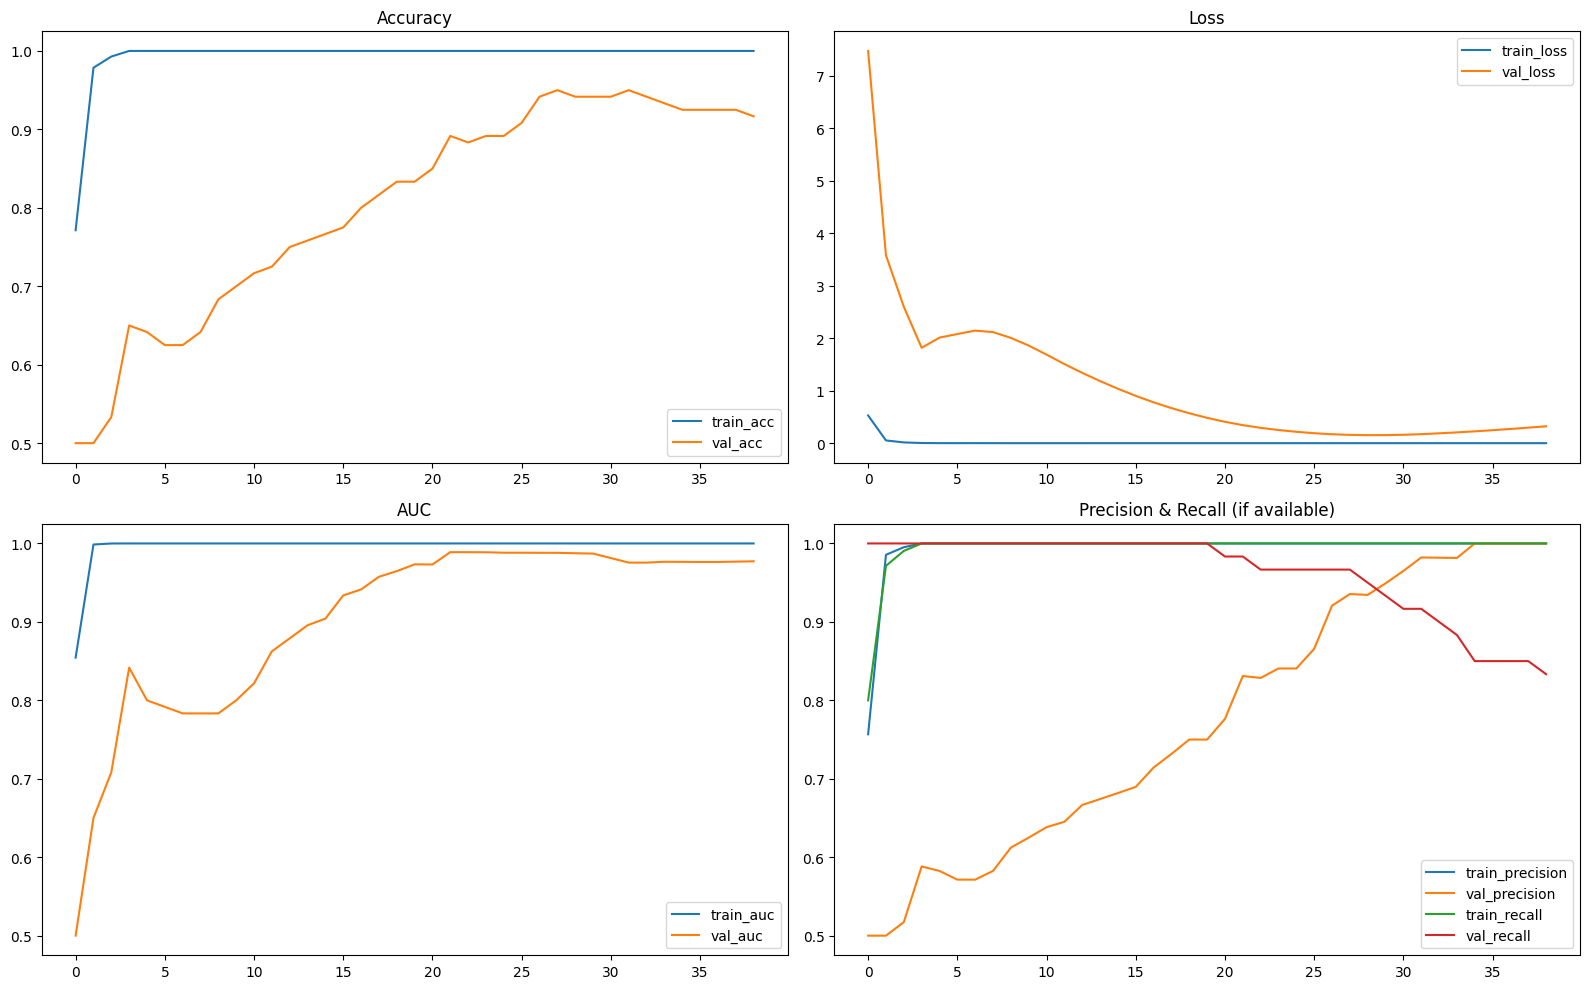

In [59]:
# --- Imports cần thiết ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

# -------------------------
# 1) Plot training metrics
# -------------------------
# Kiểm tra keys trong history
print("History keys:", list(history.history.keys()))

# Lấy các metric nếu tồn tại
def get_hist(key):
    return history.history[key] if key in history.history else None

acc = get_hist('accuracy')
val_acc = get_hist('val_accuracy')
loss = get_hist('loss')
val_loss = get_hist('val_loss')
auc = get_hist('auc')
val_auc = get_hist('val_auc')
precision = get_hist('precision')
val_precision = get_hist('val_precision')
recall = get_hist('recall')
val_recall = get_hist('val_recall')

epochs_range = range(len(history.epoch))

# Plot (tùy theo metric có tồn tại hay không)
plt.figure(figsize=(16, 10))

# Accuracy
plt.subplot(2, 2, 1)
if acc is not None:
    plt.plot(epochs_range, acc, label='train_acc')
if val_acc is not None:
    plt.plot(epochs_range, val_acc, label='val_acc')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(2, 2, 2)
if loss is not None:
    plt.plot(epochs_range, loss, label='train_loss')
if val_loss is not None:
    plt.plot(epochs_range, val_loss, label='val_loss')
plt.legend()
plt.title('Loss')

# AUC (nếu có)
plt.subplot(2, 2, 3)
if auc is not None:
    plt.plot(epochs_range, auc, label='train_auc')
if val_auc is not None:
    plt.plot(epochs_range, val_auc, label='val_auc')
plt.legend()
plt.title('AUC')

# Precision/Recall (nếu có) — vẽ chung
plt.subplot(2, 2, 4)
plotted = False
if precision is not None:
    plt.plot(epochs_range, precision, label='train_precision'); plotted=True
if val_precision is not None:
    plt.plot(epochs_range, val_precision, label='val_precision'); plotted=True
if recall is not None:
    plt.plot(epochs_range, recall, label='train_recall'); plotted=True
if val_recall is not None:
    plt.plot(epochs_range, val_recall, label='val_recall'); plotted=True
if plotted:
    plt.legend()
plt.title('Precision & Recall (if available)')

plt.tight_layout()
plt.show()



Test set: 180 samples
Using threshold = 0.9859597682952881


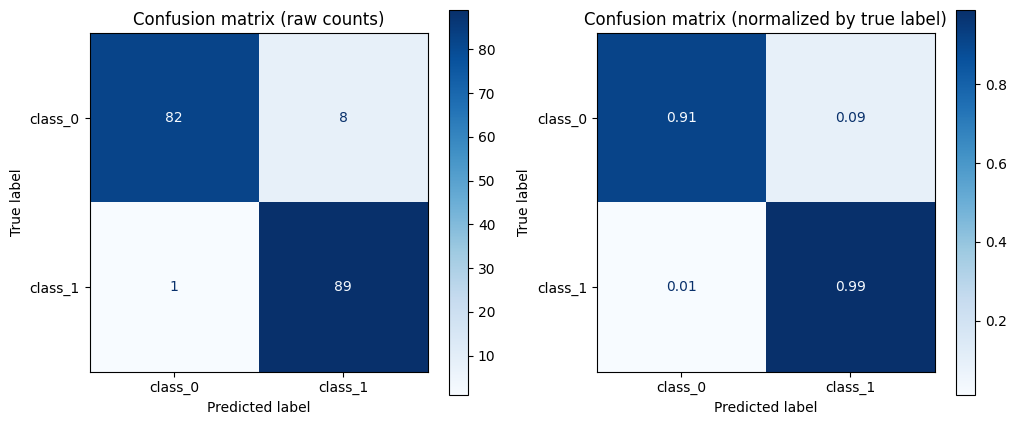


Classification report (threshold = 0.99):

              precision    recall  f1-score   support

         0.0     0.9880    0.9111    0.9480        90
         1.0     0.9175    0.9889    0.9519        90

    accuracy                         0.9500       180
   macro avg     0.9527    0.9500    0.9499       180
weighted avg     0.9527    0.9500    0.9499       180



In [60]:
# ----------------------------------------------------
# 2) Confusion matrix and classification report on test
# ----------------------------------------------------
# (a) Lấy xác suất và nhãn thật từ test_ds
# Lưu ý: test_ds đã preprocess và shuffle=False khi tạo
preds = (probs > chosen_threshold).astype(int)

# Lấy y_true từ test_ds

print(f"\nTest set: {len(y_true)} samples")
print(f"Using threshold = {chosen_threshold}")

# (b) Confusion matrix
cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['class_0','class_1'])
fig, ax = plt.subplots(1,2, figsize=(12,5))
disp.plot(ax=ax[0], values_format='d', cmap=plt.cm.Blues)
ax[0].set_title('Confusion matrix (raw counts)')

# Normalized confusion matrix
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['class_0','class_1'])
disp_norm.plot(ax=ax[1], values_format='.2f', cmap=plt.cm.Blues)
ax[1].set_title('Confusion matrix (normalized by true label)')
plt.show()

# (c) Classification report
print("\nClassification report (threshold = {:.2f}):\n".format(chosen_threshold))
print(classification_report(y_true, preds, digits=4))

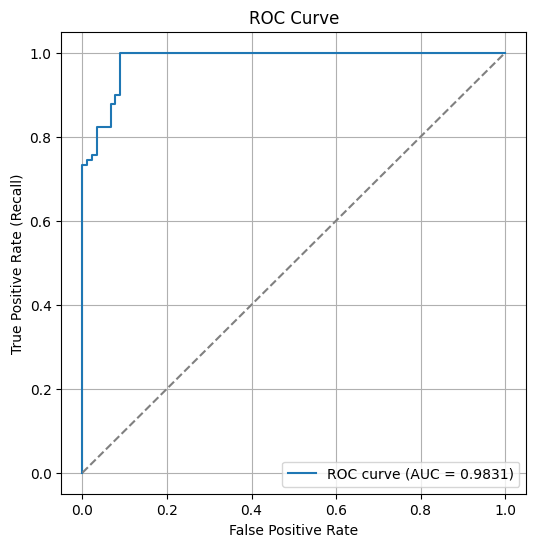

Confusion matrix counts: TN, FP, FN, TP = [82  8  1 89]
ROC AUC on test: 0.9831
Sensitivity (Recall): 0.9889, Specificity: 0.9111


In [61]:
# ----------------------------------------------------
# 3) ROC curve + ROC AUC on test set
# ----------------------------------------------------
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# (Optional) In 1 số chỉ số quan trọng
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (None,)*4
print("Confusion matrix counts: TN, FP, FN, TP =", cm.ravel() if cm.size==4 else cm)
print(f"ROC AUC on test: {roc_auc:.4f}")
if tp is not None:
    sensitivity = tp / (tp + fn + 1e-12)
    specificity = tn / (tn + fp + 1e-12)
    print(f"Sensitivity (Recall): {sensitivity:.4f}, Specificity: {specificity:.4f}")